# Predictions

### Importing packages

In [2]:
%%capture
%pip install numpy hmmlearn statsmodels arch

In [3]:
import numpy as np
from hmmlearn import hmm
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

### Generating data

In [4]:
np.random.seed(42)
calm_regime = np.random.normal(loc=0.001, scale=0.01, size=200)
choppy_regime = np.random.normal(loc=0.002, scale=0.05, size=100)
calm_again = np.random.normal(loc=0.001, scale=0.01, size=200)

data = np.concatenate([calm_regime, choppy_regime, calm_again])
X = data.reshape(-1, 1)
print(f"generated {len(X)} data points")

generated 500 data points


### Fitting the HMM

In [5]:
model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, random_state=42)
model.fit(X)

hidden_states = model.predict(X)
print(f"Current inferred hidden states: {hidden_states[-1]}")

Current inferred hidden states: 0


### Predicting the next interval state

In [6]:
last_state = hidden_states[-1]
next_state_probs = model.transmat_[last_state, :]
expected_next_state = np.argmax(next_state_probs)

next_mean = model.means_[expected_next_state][0]
next_std = np.sqrt(model.covars_[expected_next_state][0][0])

lower_bound = next_mean - 1.96 * next_std
upper_bound = next_mean + 1.96 * next_std

print(f"predicted interval for next step: [{lower_bound:.4f}, {upper_bound:.4f}]")

predicted interval for next step: [-0.0202, 0.0221]


### Scoring the prediction

In [7]:
def interval_score(actual, lower, upper, alpha=0.05):
    width = upper - lower
    if actual < lower:
        penalty = (2 / alpha) * (lower - actual)
    elif actual > upper:
        penalty = (2 / alpha) * (alpha - upper)
    else:
        penalty = 0
    return width + penalty

actual_next_step = np.random.normal(next_mean, next_std)

score = interval_score(actual_next_step, lower_bound, upper_bound)

print(f"actual value: {actual_next_step:.4f}")
print(f"interval width: {(upper_bound - lower_bound):.4f}")
print(f"final score: {score:.4f} (lower is better)")

actual value: 0.0110
interval width: 0.0423
final score: 0.0423 (lower is better)


### Testing models, global parameters

In [8]:
np.random.seed(42)
N = 250 # 250 trading days
eps = np.random.normal(0, 1, N) # Our random shocks (white noise)

### AR(1)
$$y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \varepsilon_t$$

In [9]:
y_ar = np.zeros(N)

for t in range(1, N):
    y_ar[t] = 0.6 * y_ar[t-1] + eps[t]

model_ar = ARIMA(y_ar, order=(1, 0, 0)).fit()

print(f"AR(1) next step prediction: {model_ar.forecast(1)[0]}")

AR(1) next step prediction: 0.5637649279811047


### MA(1)
$$y_t = \mu + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}$$

In [10]:
y_ma = np.zeros(N)

for t in range(1, N):
    y_ma[t] = eps[t] + 0.5 * eps[t-1]

model_ma = ARIMA(y_ma, order=(0, 0, 1)).fit()

print(f"MA(1) next step prediction: {model_ma.forecast(1)[0]}")

MA(1) next step prediction: 0.20773393172488575


### ARMA(1, 1)
$$y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}$$

In [11]:
y_arma = np.zeros(N)

for t in range(1, N):
    y_arma[t] = 0.6 * y_arma[t-1] + eps[t] + 0.5 * eps[t-1]

model_arma = ARIMA(y_arma, order=(1, 0, 1)).fit()

print(f"ARMA(1,1) next step prediction: {model_arma.forecast(1)[0]}")

ARMA(1,1) next step prediction: 1.0520083669299864


### ARIMA(1,1,1)
$$\Delta^d y_t = c + \sum_{i=1}^{p} \phi_i \Delta^d y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}$$

In [12]:
y_arima = np.cumsum(y_arma)

model_arima = ARIMA(y_arima, order=(1, 1, 1)).fit()

print(f"ARIMA(1,1,1) next step prediction: {model_arima.forecast(1)[0]}")

ARIMA(1,1,1) next step prediction: -5.305907395822687


### ARIMAX(1,1,1)
$$\Delta^d y_t = c + \dots + \sum_{k=1}^{K} \beta_k x_{k,t} + \varepsilon_t + \dots$$

In [13]:
order_flow = np.random.normal(0, 2, N)
y_arimax = y_arima + 1.5 * order_flow

model_arimax = ARIMA(y_arimax, exog=order_flow, order=(1, 1, 1)).fit()

next_order_flow = np.array([[0.5]])

print(f"ARIMAX next step prediction: {model_arimax.forecast(1, exog=next_order_flow)[0]}")

ARIMAX next step prediction: -4.546091518057164


### ARCH(1)
$$\sigma_t^2 = \omega + \sum_{j=1}^{q} \alpha_j \varepsilon_{t-j}^2$$

In [14]:
omega, alpha = 0.1, 0.6
sigma2_arch = np.zeros(N)
y_arch = np.zeros(N)

for t in range(1, N):
    sigma2_arch[t] = omega + alpha * (y_arch[t-1]**2)
    y_arch[t] = np.random.normal(0, np.sqrt(sigma2_arch[t]))

model_arch = arch_model(y_arch, vol="ARCH", p=1, rescale=False).fit(disp='off')

print(f"ARCH(1) next variance prediction: {model_arch.forecast(horizon=1).variance.iloc[-1, 0]}")

ARCH(1) next variance prediction: 0.10682349515390788


### GARCH(1,1)
$$\sigma_t^2 = \omega + \sum_{i=1}^{p} \beta_i \sigma_{t-i}^2 + \sum_{j=1}^{q} \alpha_j \varepsilon_{t-j}^2$$

In [15]:
omega, alpha, beta = 0.05, 0.15, 0.8
sigma2_garch = np.zeros(N)
y_garch = np.zeros(N)
sigma2_garch[0] = omega / (1 - alpha - beta)

for t in range(1, N):
    sigma2_garch[t] = omega + alpha * (y_garch[t-1]**2) + beta * sigma2_garch[t-1]
    y_garch[t] = np.random.normal(0, np.sqrt(sigma2_garch[t]))

model_garch = arch_model(y_garch, vol='GARCH', p=1, q=1, rescale=False).fit(disp='off')

print(f"GARCH(1,1) next variance prediction: {model_garch.forecast(horizon=1).variance.iloc[-1, 0]}")

GARCH(1,1) next variance prediction: 0.7022537867594372


### Battle Royale

Starting rolling forecast for 45 steps. This might take a few seconds...


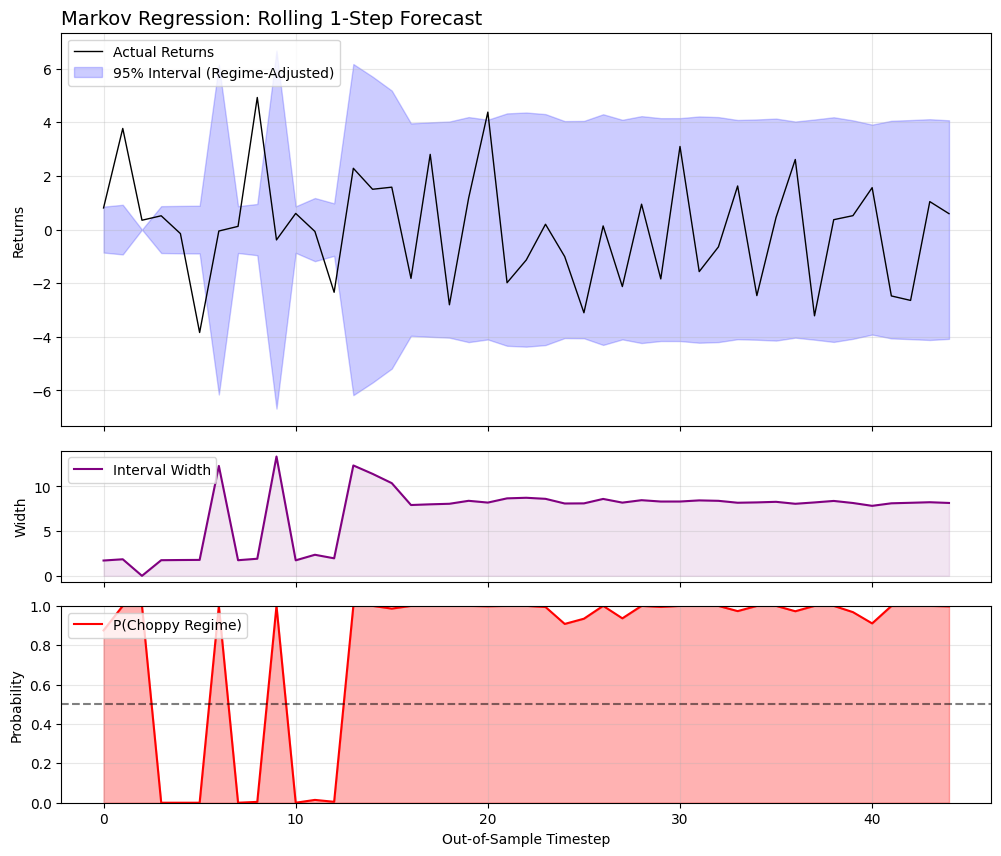

In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# ==========================================
# 1. GENERATE REGIME-SWITCHING DATA
# ==========================================
np.random.seed(42)
N = 150 
split = int(N * 0.7)

calm = np.random.normal(0, 0.5, split)
choppy = np.random.normal(0, 2.0, N - split)

# FIX: Wrap the numpy array in a pandas Series right from the start
returns = pd.Series(np.concatenate([calm, choppy]))

train_y, test_y = returns[:split], returns[split:]

# ==========================================
# 2. DEFINING THE SCORING FUNCTION
# ==========================================
def winkler_score(actual, lower, upper, alpha=0.05):
    """Vectorized Winkler Interval Score"""
    width = upper - lower
    penalty = np.where(actual < lower, (2/alpha)*(lower-actual),
              np.where(actual > upper, (2/alpha)*(actual-upper), 0))
    return np.mean(width + penalty)

# ==========================================
# 3. THE ROLLING FORECAST LOOP
# ==========================================
print(f"Starting rolling forecast for {len(test_y)} steps. This might take a few seconds...")

results = {
    "ARIMA(1,0,1)": {"mean": [], "lower": [], "upper": []},
    "GARCH(1,1)": {"mean": [], "lower": [], "upper": []},
    # FIX: Added 'prob_choppy' to track our hidden state probability
    "Markov Reg": {"mean": [], "lower": [], "upper": [], "prob_choppy": []}
}

for t in range(len(test_y)):
    history = returns[:split + t]
    
    # --- ARIMA ---
    model_arima = ARIMA(history, order=(1, 0, 1)).fit()
    fcast_arima = model_arima.get_forecast(steps=1)
    results["ARIMA(1,0,1)"]["mean"].append(fcast_arima.predicted_mean.iloc[0])
    results["ARIMA(1,0,1)"]["lower"].append(fcast_arima.conf_int().iloc[0, 0])
    results["ARIMA(1,0,1)"]["upper"].append(fcast_arima.conf_int().iloc[0, 1])
    
    # --- GARCH ---
    model_garch = arch_model(history, vol='GARCH', p=1, q=1, rescale=False).fit(disp='off')
    fcast_garch = model_garch.forecast(horizon=1)
    next_var = fcast_garch.variance.iloc[-1, 0]
    std_dev = np.sqrt(next_var)
    results["GARCH(1,1)"]["mean"].append(0) 
    results["GARCH(1,1)"]["lower"].append(0 - 1.96 * std_dev)
    results["GARCH(1,1)"]["upper"].append(0 + 1.96 * std_dev)

    # --- Markov Regression ---
    model_hmm = sm.tsa.MarkovRegression(history, k_regimes=2, switching_variance=True).fit(disp=False)
    probs = model_hmm.smoothed_marginal_probabilities.iloc[-1]
    expected_var = (probs[0] * model_hmm.params.get('sigma2[0]', 1)) + (probs[1] * model_hmm.params.get('sigma2[1]', 1))
    std_hmm = np.sqrt(expected_var)
    
    results["Markov Reg"]["mean"].append(0) 
    results["Markov Reg"]["lower"].append(0 - 1.96 * std_hmm)
    results["Markov Reg"]["upper"].append(0 + 1.96 * std_hmm)
    
    # FIX: Save the probability of being in the choppy regime (index 1)
    results["Markov Reg"]["prob_choppy"].append(probs[1])

# Convert all lists to numpy arrays for easy math/plotting
for model in results:
    for key in results[model]:
        results[model][key] = np.array(results[model][key])

# ==========================================
# 4. ADVANCED PANEL PLOTTING (HMM DASHBOARD)
# ==========================================
hmm_data = results["Markov Reg"]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True, 
                                    gridspec_kw={'height_ratios': [3, 1, 1.5]})
fig.subplots_adjust(hspace=0.1) 

# --- PANEL 1: Returns & Prediction Intervals ---
# Extracting .values from test_y just to be safe with matplotlib
ax1.plot(test_y.values, label="Actual Returns", color="black", linewidth=1)
ax1.fill_between(range(len(test_y)), hmm_data["lower"], hmm_data["upper"], 
                 color="blue", alpha=0.2, label="95% Interval (Regime-Adjusted)")
ax1.set_title("Markov Regression: Rolling 1-Step Forecast", fontsize=14, loc='left')
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylabel("Returns")

# --- PANEL 2: Interval Width (Volatility Proxy) ---
interval_width = hmm_data["upper"] - hmm_data["lower"]
ax2.plot(interval_width, color="purple", linewidth=1.5, label="Interval Width")
ax2.fill_between(range(len(test_y)), 0, interval_width, color="purple", alpha=0.1)
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_ylabel("Width")

# --- PANEL 3: Hidden State Probabilities ---
ax3.plot(hmm_data["prob_choppy"], color="red", label="P(Choppy Regime)")
ax3.fill_between(range(len(test_y)), 0, hmm_data["prob_choppy"], color="red", alpha=0.3)
ax3.axhline(0.5, color='black', linestyle='--', alpha=0.5) 
ax3.set_ylim(0, 1)
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.3)
ax3.set_ylabel("Probability")
ax3.set_xlabel("Out-of-Sample Timestep")

plt.show()